# Preparing the trial state

**Chapter focus**

> How do we prepare a state that lets phase estimation return the ground-state energy reliably?

## Learning objectives

After completing this chapter, you will be able to:

- Explain why phase estimation requires an input state.
- Define state overlap and fidelity.
- Explain how ground-state fidelity measures target-state weight and influences phase-estimation outcomes.
- Construct a sparse trial wavefunction from important determinants.
- Generate a state-preparation logical circuit with the QDK/Chemistry sparse-isometry implementation.
- Distinguish trial-state quality from state-preparation logical circuit cost.

**Lab notebook assignment**

> Complete *lab notebook trial state*.
> Record trial-state fidelity and state-preparation logical circuit statistics as separate quantities.
> Explain how determinant truncation changes the ground-state weight, its influence on phase-estimation outcomes, and the cost of preparing the trial state.

## Before you begin

This course requires a Python environment with the `qdk-chemistry[jupyter]` package.

`qdk-chemistry` ships compiled binaries for Linux, macOS on Apple silicon, and Windows on x86-64. On Windows on Arm, run this course inside WSL. Run the cell below to check the current environment.

In [ ]:
from _unit import check_env

check_env()

## Setting up

The cell below imports the QDK/Chemistry pieces this chapter uses and quiets the solver logs.

In [ ]:
import json
from collections import Counter
from collections.abc import Iterator
from dataclasses import dataclass

import numpy as np
from qdk_chemistry.algorithms import create
from qdk_chemistry.data import Circuit, Configuration, Hamiltonian, Wavefunction
from qdk_chemistry.data.symmetry import SymmetryLabel, axes
from qdk_chemistry.utils import Logger
from tutorial_choose_active_space import ActiveSpaceResult, run_active_space_workflow

@dataclass
class DeterminantContribution:
    """One determinant's contribution to the selected-space reference.

    Attributes:
        occupation: Spatial-orbital occupation string with storage padding removed.
        amplitude: CASCI coefficient after choosing the physically arbitrary
            global phase so the leading coefficient is positive real.
        weight: Squared coefficient magnitude, ``abs(amplitude)**2``.
        cumulative_weight: Sum of weights through this ranked determinant.
    """

    occupation: str
    amplitude: complex
    weight: float
    cumulative_weight: float

@dataclass
class TrialStateResult:
    r"""Quality and circuit cost for one determinant truncation.

    Fidelity is the squared overlap
    :math:`|\langle\Psi_{\mathrm{trial}}|\Psi_{\mathrm{reference}}\rangle|^2`.

    Attributes:
        num_determinants: Determinants retained by the projected calculation.
        trial_wavefunction: Normalized PMC wavefunction on the retained support.
        fidelity: Squared overlap with the selected-space CASCI ground state.
        circuit: Generated sparse-isometry state-preparation circuit.
        num_compute_qubits: Qubits in the occupation register.
        num_logical_gates: Decomposed leaf operations in the Q# circuit tree.
        logical_gate_counts: Childless-operation counts grouped by displayed gate name.
    """

    num_determinants: int
    trial_wavefunction: Wavefunction
    fidelity: float
    circuit: Circuit
    num_compute_qubits: int
    num_logical_gates: int
    logical_gate_counts: dict[str, int]

@dataclass
class TrialStateWorkflowResult:
    """Reference data and trial-state comparisons used by the chapter.

    Attributes:
        active_space_result: Coordinate-minimized selected molecular model.
        active_hamiltonian: Fermionic Hamiltonian in the selected orbital gauge.
        reference_determinants: Leading CASCI determinants for interpretation.
        trial_states: PMC/circuit results in requested determinant-count order.
    """

    active_space_result: ActiveSpaceResult
    active_hamiltonian: Hamiltonian
    reference_determinants: list[DeterminantContribution]
    trial_states: list[TrialStateResult]

In [ ]:
from tutorial_prepare_trial_state import leading_determinants

## Workflow helpers

The chapter keeps two helpers outside its excerpts: one ranks the reference determinants by weight, the other counts the leaf gates in a generated circuit. Run both so the rest of the notebook can use them.

In [ ]:
def leading_determinant_contributions(
    wavefunction: Wavefunction, max_determinants: int = 8
) -> list[DeterminantContribution]:
    """Summarize leading reference determinants and cumulative norm weight.

    Args:
        wavefunction: Selected-space CASCI reference.
        max_determinants: Number of ranked contributions to summarize.

    Returns:
        Ranked determinant records. Occupation strings are truncated to the
        physical active spatial-orbital count because ``Configuration`` storage
        can include trailing zero-valued capacity.
    """
    ranked_determinants = leading_determinants(wavefunction, max_determinants)
    leading_coefficient = complex(next(iter(ranked_determinants.values())))
    global_phase = leading_coefficient.conjugate() / abs(leading_coefficient)
    cumulative_weight = 0.0
    contributions = []
    alpha_channel = SymmetryLabel([axes.alpha()])
    num_active_spatial_orbitals = len(
        wavefunction.get_orbitals().active_indices().indices(alpha_channel)
    )
    for determinant, coefficient in ranked_determinants.items():
        # An eigenvector has arbitrary global phase. Make displayed amplitudes
        # reproducible without changing any weights, fidelities, or circuits.
        amplitude = complex(coefficient) * global_phase

        # Squared amplitudes contribute to the norm; their running sum shows how
        # much of the reference wavefunction the leading determinants capture.
        weight = float(abs(amplitude) ** 2)
        cumulative_weight += weight
        contributions.append(
            DeterminantContribution(
                # Configuration capacity may include zero-valued storage padding;
                # display only the physical selected active spatial orbitals.
                occupation=determinant.to_string()[:num_active_spatial_orbitals],
                amplitude=amplitude,
                weight=weight,
                cumulative_weight=cumulative_weight,
            )
        )
    return contributions

In [ ]:
def iter_decomposed_gate_names(value: object) -> Iterator[str]:
    """Yield normalized names for childless operations in decomposed circuit JSON.

    Args:
        value: A dictionary, list, or scalar from the nested Q# circuit JSON tree.

    Yields:
        Gate names for records without nested child operations. A controlled X is
        displayed as ``CNOT`` for this tutorial's generated circuits.

    Notes:
        The generated circuits use one-control X operations. Production tooling
        should inspect the control count before generalizing this label to
        arbitrary multi-controlled X operations.
    """
    # The circuit is a nested tree of dictionaries and lists. yield from flattens
    # recursive results into one stream of decomposed gate names.
    if isinstance(value, dict):
        children = value.get("children")

        # Composite operations contain children; only gate records without
        # nested child operations are counted.
        if isinstance(children, list) and children:
            for child in children:
                yield from iter_decomposed_gate_names(child)
        else:
            gate_name = value.get("gate")
            if isinstance(gate_name, str):
                # Q# represents CNOT as an X gate with controls; distinguish it
                # from a bare X while the full gate record is available.
                yield (
                    "CNOT" if gate_name == "X" and value.get("controls") else gate_name
                )
        # The children branch was already traversed, so skip that key while
        # checking other fields for additional nested circuit structures.
        for key, child in value.items():
            if key != "children":
                yield from iter_decomposed_gate_names(child)
    elif isinstance(value, list):
        for child in value:
            yield from iter_decomposed_gate_names(child)


def circuit_statistics(circuit: Circuit) -> tuple[int, int, dict[str, int]]:
    """Count qubits and decomposed logical operations in a generated circuit.

    Args:
        circuit: State-preparation circuit whose Q# representation will be
            traversed recursively.

    Returns:
        A tuple containing the qubit count, total decomposed-gate count, and a
        deterministic gate-family count mapping.
    """
    # Convert the Q# circuit JSON to ordinary Python containers, then flatten
    # composite operations to the childless gate records that contribute to the count.
    circuit_data = json.loads(circuit.get_qsharp_circuit().json())
    logical_gate_names = list(iter_decomposed_gate_names(circuit_data))
    logical_gate_counts = Counter(logical_gate_names)
    return (
        len(circuit_data["qubits"]),
        len(logical_gate_names),
        dict(sorted(logical_gate_counts.items())),
    )

## Connection to the selected-space workflow

The *selected-space CASCI calculation* produced a normalized ground-state wavefunction spanning the $(n_\alpha,n_\beta)=(3,3)$ determinant sector introduced in *Mapping the problem to qubits*.
Each determinant represents one pattern of occupations among the selected active spin orbitals, and its coefficient is the corresponding amplitude in the wavefunction.
The *Jordan–Wigner encoding* represents the same occupation patterns on the compute register sized in *Mapping the problem to qubits*.

## Why phase estimation needs a trial state

Quantum phase estimation (QPE) estimates an eigenphase of a unitary operator.
For molecular energies, that unitary represents evolution under the Hamiltonian: each Hamiltonian eigenstate is also an eigenstate of the time-evolution operator, and its phase depends on its energy.
The phase-to-energy relationship and the QPE logical circuit are developed in the next chapter.
For now, the important point is that the compute register must contain a chosen quantum state before phase estimation can begin.

A state-preparation logical circuit initializes the compute register in this chosen normalized quantum state.
Here, *logical* means gates in the generated algorithmic circuit before error-correction code synthesis and hardware mapping.
This input is the trial state.
It is an approximation intended to contain a substantial contribution from the target ground state; QPE cannot begin from an unspecified state or create the ground state by searching through all possible wavefunctions.

The trial state can be written as a linear combination of the eigenstates $\{\vert\Psi_j\rangle\}$ of the active-space Hamiltonian:

$$
\vert\Psi_{\mathrm{trial}}\rangle
= \sum_j a_j\vert\Psi_j\rangle,
\qquad
\sum_j \left\vert a_j\right\vert^2=1.
$$

To isolate the effect of the input state, first assume that the requested trial state is prepared exactly, time evolution is exact, and phase readout has enough resolution to distinguish the relevant eigenphases.
Under these assumptions, an input eigenstate $\vert\Psi_j\rangle$ produces the phase corresponding to $E_j$.
For a trial state containing several eigenstates, a textbook coherent phase-estimation measurement samples the energy $E_j$ with probability $\left\vert a_j\right\vert^2$.
This probability statement assumes that one prepared system state produces one complete phase result.

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>Why can phase estimation return an excited-state energy even when the ground-state energy is the target?</b></summary>

A trial state can contain both ground- and excited-state eigenvectors.
Under the assumptions above, phase estimation returns each represented eigenvalue with probability equal to the squared magnitude of that eigenstate's amplitude in the trial state.

</details>
</div>

## Ground-state fidelity

As *introduced in the tutorial overview*, the ground-state fidelity is the squared overlap

$$
F
= \left\vert
    \langle\Psi_0\vert\Psi_{\mathrm{trial}}\rangle
  \right\vert^2.
$$

Both states are normalized, so $0\leq F\leq 1$.
The fidelity $F$ is the weight of the target ground state in the trial-state eigenstate expansion.
For the textbook coherent measurement described above, it is also the probability of sampling the ground-state eigenphase.

The QDK/Chemistry iterative quantum phase estimation (IQPE) implementation used later performs a different sampling procedure.
Each *phase bit* is one binary digit of the estimated phase fraction.
The implementation builds a separate circuit for each phase bit, and every circuit execution freshly prepares the trial state.
Each phase bit is selected by a majority vote over a specified number of circuit executions, then used as feedback for the next bit.
The final bit string therefore combines bitwise decisions from many state preparations rather than recording one eigenstate sample.

Fidelity remains a useful trial-state quality measure because it controls the ground-state contribution to those bit statistics.
However, it is not by itself the probability that one complete implemented IQPE run returns the ground-state energy, so it does not determine a trial count.
The complete result also depends on the other eigenstate weights and phases, the number of phase bits, shots per bit, phase feedback, and the Hamiltonian-simulation approximation.
The next chapter develops this bitwise sampling procedure and evaluates repeated complete IQPE runs.

Imperfect logical state preparation can also change the state actually loaded.
Residual logical faults after error correction can introduce further errors on a fault-tolerant machine, but they are not modeled by this tutorial's simulator.
These effects should be evaluated separately from the fidelity of the intended trial state.

## Running the reference workflow

Everything below builds on the selected active space from the previous chapter. This cell reruns that workflow, builds the active-space Hamiltonian, and ranks the leading reference determinants. It is the expensive step in the chapter.

In [ ]:
active_space_result = run_active_space_workflow()
reference_wavefunction = active_space_result.refined_casci_wavefunction
selected_orbitals = active_space_result.refined_wavefunction.get_orbitals()
active_hamiltonian = create("hamiltonian_constructor", "qdk").run(
    selected_orbitals
)

reference_determinants = leading_determinant_contributions(
    reference_wavefunction
)
for contribution in reference_determinants[:4]:
    print(
        f"{contribution.occupation}  "
        f"amplitude {contribution.amplitude.real:+.4f}  "
        f"weight {contribution.weight:.4f}  "
        f"cumulative {contribution.cumulative_weight:.4f}"
    )

The two excerpts that follow are one pass of the script's loop over one, two, and four determinants. Fix the count here so they can run as ordinary cells.

In [ ]:
num_determinants = 4

## A sparse trial wavefunction

The selected-space CASCI wavefunction is classically tractable in this teaching example, so it provides a controlled reference for comparing trial states.
The script ranks its determinants by coefficient magnitude and retains the largest one, two, or four.
These determinant counts are examples rather than restrictions of the projected calculation or state-preparation method.
To compare other choices, change `determinant_counts` in the Jupyter notebook and rerun its cells.
In a larger problem where exact CASCI is unavailable, an approximate classical method must supply the candidate determinants and amplitudes for the trial state.

The script first prints the leading terms in the selected-space wavefunction.
Each occupation string contains one symbol for each selected active spatial orbital: `2` means doubly occupied, `u` means occupied by one $\alpha$ electron, `d` means occupied by one $\beta$ electron, and `0` means unoccupied.
The amplitude is the signed coefficient $c_I$ in $\vert\Psi_0\rangle=\sum_I c_I\vert\Phi_I\rangle$, while the weight $\left\vert c_I\right\vert^2$ is that determinant's contribution to the squared norm.
The cumulative weight shows how much of the norm is captured by the listed determinants.
The script computes these quantities directly from the leading CASCI coefficients.

Simply discarding coefficients and renormalizing would not optimize the wavefunction within the retained determinant space because the full-space amplitudes are not generally the amplitudes that minimize energy after determinants are removed.
A projected multi-configuration (PMC) calculation is a configuration-interaction calculation restricted to a user-specified set of determinants.
The QDK/Chemistry PMC calculator instead constructs the Hamiltonian matrix in the retained determinant space and solves its eigenvalue problem for the lowest-energy normalized eigenvector.
The resulting projected wavefunction has zero amplitude on every omitted determinant.
When using the projected wavefunction as a trial state, its overlap with the complete selected-space CASCI wavefunction therefore quantifies how much fidelity is retained after determinant truncation.

Under the *Jordan–Wigner encoding*, each retained determinant becomes one computational-basis state of the compute register.
The trial wavefunction is therefore

$$
\vert\Psi_{\mathrm{trial}}\rangle
=\sum_{I=1}^{K}\widetilde{c}_I\vert b_I\rangle,
$$

where $\vert b_I\rangle$ is the occupation bitstring for retained determinant $\Phi_I$, and $\widetilde{c}_I$ is its reoptimized amplitude.

The script constructs each projected trial state, forms the reference and trial coefficient vectors for the same retained determinants, and evaluates their squared inner product directly:

In [ ]:
# The leading reference determinants define the trial-state support;
# PMC then reoptimizes their amplitudes within that restricted space.
top_determinants = leading_determinants(
    reference_wavefunction, num_determinants
)
projected_calculator = create(
    "projected_multi_configuration_calculator", "macis_pmc"
)
_, trial_wavefunction = projected_calculator.run(
    active_hamiltonian, list(top_determinants)
)
retained_determinants = trial_wavefunction.get_active_determinants()

# Read both vectors in PMC determinant order. Without this alignment,
# np.vdot() could multiply coefficients belonging to different determinants.
reference_coefficients = np.asarray(
    [
        reference_wavefunction.get_coefficient(determinant)
        for determinant in retained_determinants
    ]
)
trial_coefficients = np.asarray(
    [
        trial_wavefunction.get_coefficient(determinant)
        for determinant in retained_determinants
    ]
)

# The trial vector is normalized on the retained support. The reference
# entries keep their full-state normalization, so their restricted norm
# records weight omitted by truncation.
fidelity = float(abs(np.vdot(reference_coefficients, trial_coefficients)) ** 2)

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>Why must fidelity be calculated separately from the PMC energy?</b></summary>

The PMC calculation chooses the lowest-energy wavefunction within the retained determinant space, but it does not directly maximize overlap with the complete selected-space ground state.
Energy and overlap measure different properties, so the script evaluates fidelity explicitly.

</details>
</div>

## The trial state preparation logical circuit

The QDK/Chemistry sparse-isometry implementation converts the retained determinants into a binary matrix whose rows represent qubits and whose columns represent occupied-or-unoccupied patterns.
The method uses binary row operations to reduce the determinant patterns while recording controlled-NOT (CNOT) and X operations, prepares the reduced set of amplitudes, and reverses the recorded operations to expand the state across the compute register, in an optimized version of approaches introduced by Malvetti et al..
Students do not need to reproduce this synthesis by hand; it is implemented natively in QDK/Chemistry.
The important input is the normalized sparse wavefunction and the output is a logical circuit that prepares its amplitudes on the corresponding occupation states.

Some compute-register wires may have no gates in the state-preparation circuit.
The register begins in the all-zero occupation state, so a wire needs no preparation operation when the selected sparse wavefunction does not require that occupation bit to change or become entangled.
This does not make the qubit unnecessary: every compute qubit represents an active spin orbital on which the mapped active-space Hamiltonian acts.
The later controlled time evolution in QPE therefore requires the complete compute register and can couple the prepared determinant support to other configurations in the same sector.
Removing a gate-free preparation wire would change the Hamiltonian representation and the molecular problem, rather than merely simplify state preparation.

![Side-by-side logical state-preparation circuits on twelve compute qubits. The one-determinant circuit on the left contains six X gates that prepare one occupation bit string. The two-determinant circuit on the right contains rotations and controlled operations that prepare a coherent superposition of two occupation bit strings.](attachment:tutorial_qpe_state_preparation_comparison.png)

*Generated logical state-preparation circuits for the one-determinant trial state (left) and two-determinant trial state (right). Both use the same twelve-qubit compute register; the additional operations prepare multiple amplitudes rather than additional spin orbitals.*
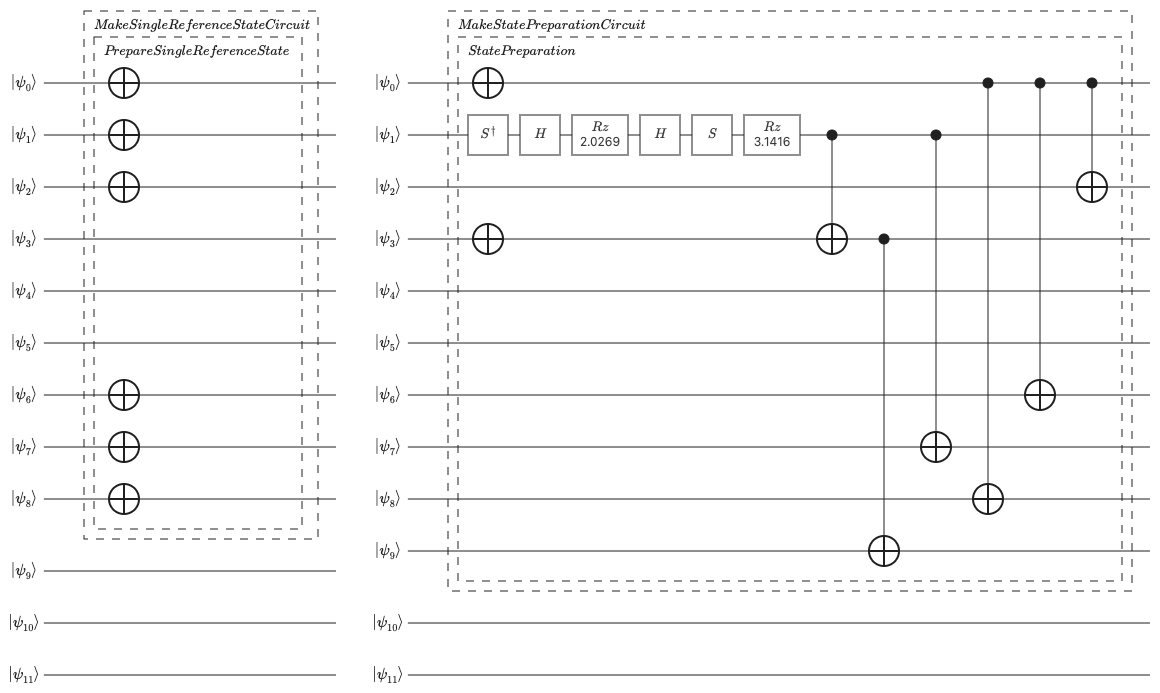

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>Why does one-determinant state preparation look so different from multi-determinant preparation?</b></summary>

One determinant is one occupation bit string and therefore one computational-basis state.
Starting from the all-zero state, X gates only need to flip the qubits representing occupied spin orbitals.
A multi-determinant wavefunction is instead a coherent superposition of distinct occupation bit strings.
Because X gates can only map one basis state to another, rotations are needed to create amplitudes, phase operations establish relative signs or phases, and entangling gates correlate occupation changes across qubits.
The exact gate sequence depends on the synthesis method, but the distinction between preparing one basis state and preparing a coherent superposition is general.

</details>
</div>

To measure the generated logical-circuit cost, the script traverses the decomposed *Q# circuit representation*, counts displayed gate records that have no nested child operations, and identifies controlled X gates as CNOT gates.
The script creates the QDK/Chemistry sparse-isometry implementation and inspects the generated Q# logical circuit.
The factory key *sparse_isometry_gf2x* is the implementation's current API identifier using a helper function to count gates:

In [ ]:
state_preparation = create("state_prep", "sparse_isometry_gf2x")
circuit = state_preparation.run(trial_wavefunction)
num_compute_qubits, num_logical_gates, logical_gate_counts = circuit_statistics(
    circuit
)

The reported *preparation logical gate count* is the number of these childless gate records in the generated Q# logical-circuit representation after the state-preparation operation has been decomposed.
This software-level logical gate count is not logical-circuit depth, a fault-tolerant resource estimate, or a physical-resource estimate.
It can change if the state-preparation or circuit-decomposition implementation changes; error correction affects downstream fault-tolerant and physical costs instead.

The chapter reports the circuit cost from a printing function that sits outside its excerpts, so the numbers it discusses are shown here.

In [ ]:
print(f"Compute qubits: {num_compute_qubits}")
print(f"Preparation logical gate count: {num_logical_gates}")
print(f"Logical gate-family counts: {logical_gate_counts}")

## Trial-state quality and preparation cost

Trial-state truncation introduces a separate cost–quality tradeoff within the selected active space.
Retaining more determinants can improve fidelity with the selected-space ground state, but preparing more nonzero amplitudes generally requires more logical gates.
The relevant question is therefore how much fidelity is gained for each increase in state-preparation cost.

All three trial states describe the same selected active spin-orbital space, so they use the same compute register size.
Changing the number of retained determinants changes amplitudes and logical-circuit structure, not the number of spin orbitals represented.

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>Does retaining more determinants require more compute qubits?</b></summary>

No.
Each trial state represents the same selected active spin-orbital space, so the compute-register size is unchanged.
The number of retained determinants affects state-preparation operations rather than the compute-register size.

</details>
</div>

## Comparing the three trial states

The script repeats the same construction for one, two, and four determinants. Repeat it here to see how fidelity responds to the retained determinant count.

In [ ]:
from tutorial_prepare_trial_state import run_trial_state_workflow

comparison = run_trial_state_workflow()
fidelities = {
    trial.num_determinants: trial.fidelity
    for trial in comparison.trial_states
}
for count, fidelity in fidelities.items():
    print(f"{count} determinants: fidelity {fidelity:.4f}")

## Running the preparation

The cells above have already run the preparation. Use their output to answer the questions below.

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>How do fidelity and preparation cost change as determinants are retained?</b></summary>

The one-, two-, and four-determinant fidelities are approximately $0.4825$, $0.5864$, and $0.7324$, respectively.
Their generated logical circuits have preparation logical gate counts of 6, 14, and 30, respectively, while every logical circuit uses twelve compute qubits.
From one to two determinants, fidelity increases by approximately $0.104$ while the gate count increases by eight.
From two to four determinants, fidelity increases by approximately $0.146$ while the gate count increases by sixteen.
For these three generated circuits, the second expansion provides less fidelity gain per additional preparation gate than the first.

</details>
</div>

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>What does the single-determinant fidelity reveal about multireference character?</b></summary>

Its fidelity is approximately $0.4825$, equal to the weight of the leading `222000` determinant.
No single determinant therefore carries a majority of the selected-space ground-state weight at this geometry.
The substantial weight distributed among additional determinants provides direct evidence of multireference character in the selected active-space orbital representation.

</details>
</div>

Record the leading reference determinants and all three determinant counts, fidelities, compute-qubit counts, preparation logical gate counts, and logical gate-family counts in the *trial-state section of the lab notebook*.
Explain what the leading determinant weight reveals about multireference character, and distinguish the fidelity improvement from the increased logical-circuit cost.
The final IQPE calculation uses the four-determinant trial state.
In the lab notebook, use your measured fidelities and preparation logical gate counts to evaluate this choice and describe what would be gained or lost by using one of the smaller trial states instead.

## Where truncation starts to pay off

A single determinant carries less than half the weight of the selected-space ground state. That is the direct evidence of multireference character, and it is why one determinant is not enough to start phase estimation from.

Complete `first_majority_count` so it returns the smallest determinant count in `fidelities` whose fidelity is greater than 0.5.

In [ ]:
from _unit import exercise


@exercise
def first_majority_count():
    return 1

**Hint**

`fidelities` maps a determinant count to its fidelity. Walk the counts in increasing order and return the first one whose value clears 0.5.

**Solution**

```python
@exercise
def first_majority_count():
    return min(c for c, f in fidelities.items() if f > 0.5)
```

Two determinants. The one-determinant fidelity is about 0.4825, so no single configuration holds a majority of the ground state at this stretched geometry.

## Further reading

- *State preparation*
- *Projected multi-configuration calculations*
- *Wavefunctions*
- *Quantum circuits*